# Geo Clustering for Elder-Volunteer Matching

This notebook clusters elders and youth volunteers together using DBSCAN with haversine distance (scikit-learn).

Outputs:
- `elderly_with_clusters.csv`
- `youth_with_clusters.csv`

In [3]:
%pip install pandas numpy scikit-learn matplotlib

  Using cached matplotlib-3.10.8-cp314-cp314-macosx_11_0_arm64.whl.metadata (52 kB)
  Using cached contourpy-1.3.3-cp314-cp314-macosx_11_0_arm64.whl.metadata (5.5 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached fonttools-4.62.1-cp314-cp314-macosx_10_15_universal2.whl.metadata (117 kB)
  Using cached kiwisolver-1.5.0-cp314-cp314-macosx_11_0_arm64.whl.metadata (5.1 kB)
  Using cached pyparsing-3.3.2-py3-none-any.whl.metadata (5.8 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.9/9.9 MB 44.6 MB/s  0:00:00m0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.2/5.2 MB 23.9 MB/s  0:00:00 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.1/8.1 MB 32.6 MB/s  0:00:00 eta 0:00:01
Using cached matplotlib-3.10.8-cp314-cp314-macosx_11_0_arm64.whl (8.2 MB)
Using cached contourpy-1.3.3-cp314-cp314-macosx_11_0_arm64.whl (273 kB)
Using cached cycler-0.12.1-py3-none-any.whl (8.3 kB)
Using cached fonttools-4.62.1-cp314-cp314-macosx_10_15_universal2.whl (2.9 M

In [36]:
import numpy as np
import pandas as pd
from sklearn.cluster import DBSCAN
import matplotlib.pyplot as plt

In [58]:
ELDERLY_PATH = 'fake_elderly_profiles.csv'
YOUTH_PATH = 'fake_youth_profiles.csv'

EPS_KM = 0.2
MIN_SAMPLES = 15

EARTH_RADIUS_KM = 6371.0088
EPS_RAD = EPS_KM / EARTH_RADIUS_KM

In [38]:
elder = pd.read_csv(ELDERLY_PATH)
young = pd.read_csv(YOUTH_PATH)

elder['type'] = 'elderly'
young['type'] = 'youth'

In [43]:
new = pd.concat([elder, young], ignore_index=True)
new = new.dropna(subset=['latitude', 'longitude']).copy()
new[['latitude', 'longitude']] = new[['latitude', 'longitude']].astype(float)

print('Total rows:', len(new))
new[['type']].value_counts()

Total rows: 5500


type   
elderly    3000
youth      2500
Name: count, dtype: int64

In [53]:
cords = np.radians(new[["latitude","longitude"]].to_numpy())
cords

array([[0.38896977, 1.99365992],
       [0.3888999 , 1.99221265],
       [0.39285496, 1.99185518],
       ...,
       [0.38854401, 1.99382047],
       [0.38968411, 1.99239277],
       [0.38906384, 1.99323107]], shape=(5500, 2))

In [59]:
db = DBSCAN(eps=EPS_RAD, min_samples=MIN_SAMPLES, metric='haversine').fit(cords)
db.labels_

array([-1, -1, -1, ..., 10, -1,  5], shape=(5500,))

## Simple DBSCAN (Recommended)
Run this single cell for a clean, practical result. It uses a good default radius for your data and prints easy diagnostics.

In [82]:
import numpy as np
import pandas as pd
from sklearn.cluster import DBSCAN

elder = pd.read_csv('fake_elderly_profiles.csv')
youth = pd.read_csv('fake_youth_profiles.csv')
elder['type'] = 'elderly'
youth['type'] = 'youth'

all_people = pd.concat([elder, youth], ignore_index=True)
all_people = all_people.dropna(subset=['latitude', 'longitude']).copy()

# Good default for your synthetic HK-style data
eps_km = 0.5
min_samples = 12
eps_rad = eps_km / 6371.0088

coords = np.radians(all_people[['latitude', 'longitude']].to_numpy())
labels = DBSCAN(eps=eps_rad, min_samples=min_samples, metric='haversine', algorithm='ball_tree').fit_predict(coords)

all_people['cluster_id'] = labels

n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
n_noise = int((labels == -1).sum())
largest_cluster = int(pd.Series(labels).value_counts().max())

print(f'clusters={n_clusters}, noise={n_noise}, largest_cluster={largest_cluster}')
pd.Series(labels).value_counts().head(10)

clusters=16, noise=10, largest_cluster=1943


3     1943
0     1665
5      248
6      213
1      169
9      154
8      153
11     147
12     135
7      126
Name: count, dtype: int64

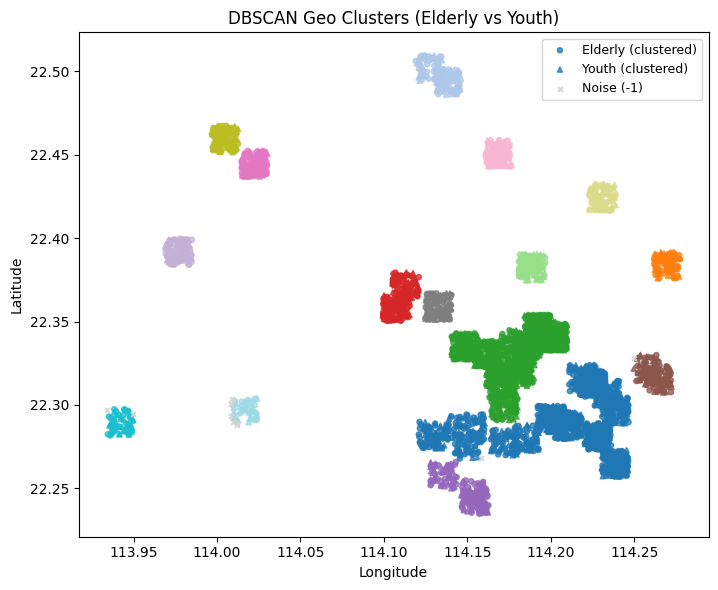

In [66]:
# Clearer cluster visualization: color by cluster, marker by person type
plt.figure(figsize=(8, 6))

plot_df = all_people.copy()
clustered = plot_df[plot_df['cluster_id'] != -1]
noise = plot_df[plot_df['cluster_id'] == -1]

# Elders
eld = clustered[clustered['type'] == 'elderly']
plt.scatter(
    eld['longitude'], eld['latitude'],
    c=eld['cluster_id'], cmap='tab20', s=14, alpha=0.75, marker='o',
    label='Elderly (clustered)'
)

# Youth
yth = clustered[clustered['type'] == 'youth']
plt.scatter(
    yth['longitude'], yth['latitude'],
    c=yth['cluster_id'], cmap='tab20', s=14, alpha=0.75, marker='^',
    label='Youth (clustered)'
)

# Noise points
if len(noise) > 0:
    plt.scatter(
        noise['longitude'], noise['latitude'],
        c='lightgray', s=12, alpha=0.9, marker='x',
        label='Noise (-1)'
    )

plt.title('DBSCAN Geo Clusters (Elderly vs Youth)')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.gca().set_aspect('equal', adjustable='box')
plt.legend(loc='best', fontsize=9)
plt.tight_layout()
plt.show()

In [ ]:
# DBSCAN evaluation metrics (quality + matching readiness)
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score

eval_df = all_people.copy()
labels = eval_df['cluster_id'].to_numpy()

# Exclude noise for intrinsic cluster metrics
mask = labels != -1
X = eval_df.loc[mask, ['latitude', 'longitude']].to_numpy()
y = labels[mask]

unique_clusters = np.unique(y)
if len(unique_clusters) >= 2 and len(X) > len(unique_clusters):
    sil = silhouette_score(X, y)
    dbi = davies_bouldin_score(X, y)
    chi = calinski_harabasz_score(X, y)
else:
    sil, dbi, chi = np.nan, np.nan, np.nan

# Matching-readiness metrics
non_noise = eval_df[eval_df['cluster_id'] != -1].copy()
mix = non_noise.groupby(['cluster_id', 'type']).size().unstack(fill_value=0)
if 'elderly' not in mix.columns:
    mix['elderly'] = 0
if 'youth' not in mix.columns:
    mix['youth'] = 0

mix['balanced'] = (mix['elderly'] > 0) & (mix['youth'] > 0)
balanced_cluster_rate = float(mix['balanced'].mean()) if len(mix) else 0.0

balanced_ids = set(mix.index[mix['balanced']])
elder_non_noise = non_noise[non_noise['type'] == 'elderly']
elder_covered = elder_non_noise['cluster_id'].isin(balanced_ids).mean() if len(elder_non_noise) else 0.0

noise_ratio = float((eval_df['cluster_id'] == -1).mean())
largest_cluster_ratio = float(eval_df['cluster_id'].value_counts(normalize=True).max())

print('=== Intrinsic Cluster Quality ===')
print(f'Silhouette score        : {sil:.4f}')
print(f'Davies-Bouldin index    : {dbi:.4f} (lower is better)')
print(f'Calinski-Harabasz score : {chi:.2f} (higher is better)')

print('\n=== Matching Readiness ===')
print(f'Balanced cluster rate   : {balanced_cluster_rate:.2%}')
print(f'Elderly coverage (non-noise, balanced clusters): {elder_covered:.2%}')
print(f'Noise ratio             : {noise_ratio:.2%}')
print(f'Largest cluster ratio   : {largest_cluster_ratio:.2%}')

mix.sort_values(['balanced', 'elderly', 'youth'], ascending=[False, False, False]).head(15)

=== Intrinsic Cluster Quality ===
Silhouette score        : 0.4084
Davies-Bouldin index    : 0.4767 (lower is better)
Calinski-Harabasz score : 4552.05 (higher is better)

=== Matching Readiness ===
Balanced cluster rate   : 100.00%
Elderly coverage (non-noise, balanced clusters): 100.00%
Noise ratio             : 0.18%
Largest cluster ratio   : 35.33%


type,elderly,youth,balanced
cluster_id,,,
3,1062,881,True
0,917,748,True
5,132,116,True
6,113,100,True
1,100,69,True
8,87,66,True
9,80,74,True
11,78,69,True
12,73,62,True


## K-Means for Location (Bigger, Fewer Clusters)
Use this section if you want broad location zones instead of many small clusters.

In [69]:
# Quick k-selection helper (smaller k -> bigger clusters)
from sklearn.metrics import silhouette_score

X_km = all_people[['latitude', 'longitude']].to_numpy()
rows = []
for k_try in range(4, 13):
    km_try = KMeans(n_clusters=k_try, random_state=42, n_init=20)
    labels_try = km_try.fit_predict(X_km)
    sil_try = silhouette_score(X_km, labels_try)
    largest_try = pd.Series(labels_try).value_counts().max() / len(labels_try)
    rows.append((k_try, sil_try, largest_try))

k_check = pd.DataFrame(rows, columns=['k', 'silhouette', 'largest_cluster_ratio'])
k_check

,k,silhouette,largest_cluster_ratio
0,4,0.414503,0.540182
1,5,0.459004,0.429273
2,6,0.471849,0.429273
3,7,0.501086,0.334545
4,8,0.543092,0.343273
5,9,0.524682,0.263455
6,10,0.515763,0.206909
7,11,0.522728,0.207091
8,12,0.535938,0.206909


K-Means clusters: 8
Largest cluster size: 1888
Largest cluster ratio: 0.3433


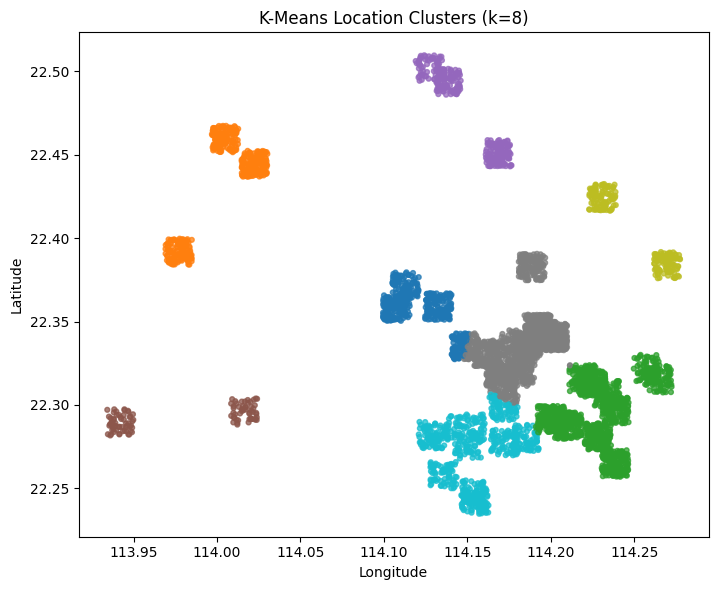

In [83]:
from sklearn.cluster import KMeans

# Fewer, bigger location clusters
k = 8

km_df = all_people.copy()
X_km = km_df[['latitude', 'longitude']].to_numpy()

kmeans = KMeans(n_clusters=k, random_state=42, n_init=20)
km_labels = kmeans.fit_predict(X_km)
km_df['kmeans_cluster'] = km_labels

print('K-Means clusters:', km_df['kmeans_cluster'].nunique())
print('Largest cluster size:', int(km_df['kmeans_cluster'].value_counts().max()))
print('Largest cluster ratio:', round(km_df['kmeans_cluster'].value_counts(normalize=True).max(), 4))
km_df['kmeans_cluster'].value_counts().head(10)

# Quick plot
plt.figure(figsize=(8, 6))
plt.scatter(
    km_df['longitude'], km_df['latitude'],
    c=km_df['kmeans_cluster'], cmap='tab10', s=12, alpha=0.75
)
plt.title(f'K-Means Location Clusters (k={k})')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.gca().set_aspect('equal', adjustable='box')
plt.tight_layout()
plt.show()

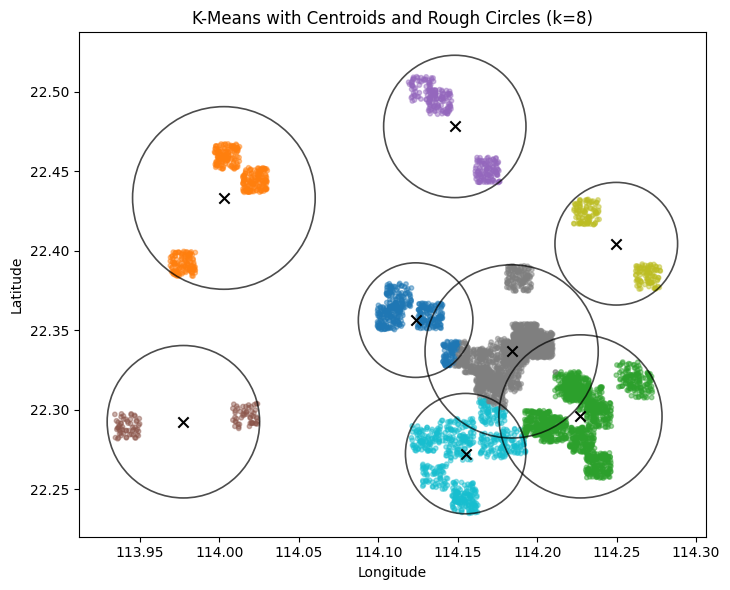

In [71]:
# Optional: show K-Means centroids and rough circles
from matplotlib.patches import Circle

plt.figure(figsize=(8, 6))
ax = plt.gca()

# Plot points by cluster
plt.scatter(
    km_df['longitude'], km_df['latitude'],
    c=km_df['kmeans_cluster'], cmap='tab10', s=10, alpha=0.45
 )

# Centroids are in [latitude, longitude] order
centroids = kmeans.cluster_centers_

for i, c in enumerate(centroids):
    c_lat, c_lon = c[0], c[1]
    pts = km_df[km_df['kmeans_cluster'] == i][['latitude', 'longitude']].to_numpy()

    # Radius = farthest point from centroid (in degree space, for visualization only)
    d = np.sqrt((pts[:, 0] - c_lat) ** 2 + (pts[:, 1] - c_lon) ** 2)
    r = float(d.max()) if len(d) else 0.0

    # Draw centroid
    plt.scatter(c_lon, c_lat, c='black', s=55, marker='x')

    # Draw rough circle around cluster
    circ = Circle((c_lon, c_lat), r, fill=False, edgecolor='black', linewidth=1.2, alpha=0.7)
    ax.add_patch(circ)

plt.title(f'K-Means with Centroids and Rough Circles (k={k})')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.gca().set_aspect('equal', adjustable='box')
plt.tight_layout()
plt.show()

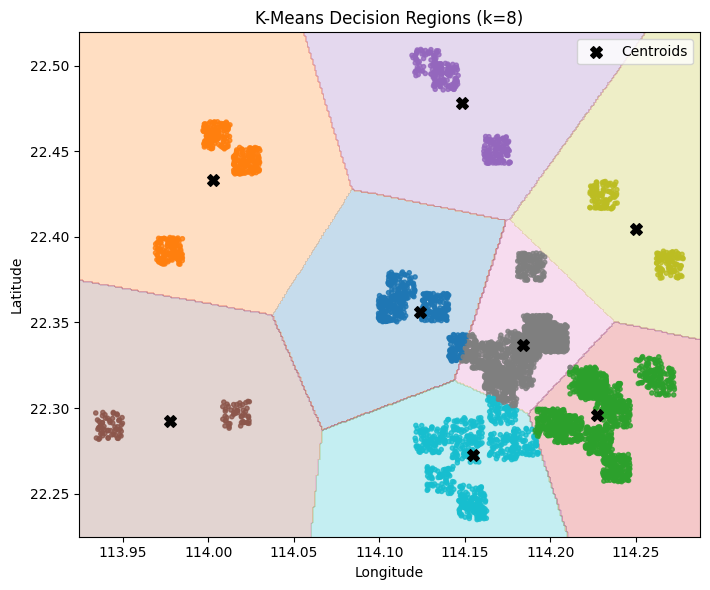

In [72]:
# K-Means decision boundary map (Voronoi-style regions)
lat_min, lat_max = km_df['latitude'].min() - 0.01, km_df['latitude'].max() + 0.01
lon_min, lon_max = km_df['longitude'].min() - 0.01, km_df['longitude'].max() + 0.01

lat_grid = np.linspace(lat_min, lat_max, 350)
lon_grid = np.linspace(lon_min, lon_max, 350)
xx, yy = np.meshgrid(lon_grid, lat_grid)

# KMeans expects [latitude, longitude]
grid_points = np.c_[yy.ravel(), xx.ravel()]
grid_labels = kmeans.predict(grid_points).reshape(xx.shape)

plt.figure(figsize=(8, 6))
plt.contourf(xx, yy, grid_labels, levels=np.arange(k + 1) - 0.5, cmap='tab10', alpha=0.25)

# Plot actual points
plt.scatter(
    km_df['longitude'], km_df['latitude'],
    c=km_df['kmeans_cluster'], cmap='tab10', s=9, alpha=0.8
 )

# Plot centroids (convert [lat, lon] -> [lon, lat])
cent = kmeans.cluster_centers_
plt.scatter(cent[:, 1], cent[:, 0], c='black', s=70, marker='X', label='Centroids')

plt.title(f'K-Means Decision Regions (k={k})')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.gca().set_aspect('equal', adjustable='box')
plt.legend(loc='best')
plt.tight_layout()
plt.show()

In [85]:
# DBSCAN vs K-Means: side-by-side comparison
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score

comp_rows = []

# --- DBSCAN metrics (exclude noise for intrinsic metrics)
db_df = all_people.copy()
db_labels = db_df['cluster_id'].to_numpy()
db_mask = db_labels != -1
db_X = db_df.loc[db_mask, ['latitude', 'longitude']].to_numpy()
db_y = db_labels[db_mask]

if len(np.unique(db_y)) >= 2 and len(db_X) > len(np.unique(db_y)):
    db_sil = silhouette_score(db_X, db_y)
    db_dbi = davies_bouldin_score(db_X, db_y)
    db_chi = calinski_harabasz_score(db_X, db_y)
else:
    db_sil, db_dbi, db_chi = np.nan, np.nan, np.nan

db_non_noise = db_df[db_df['cluster_id'] != -1].copy()
db_mix = db_non_noise.groupby(['cluster_id', 'type']).size().unstack(fill_value=0)
if 'elderly' not in db_mix.columns:
    db_mix['elderly'] = 0
if 'youth' not in db_mix.columns:
    db_mix['youth'] = 0
db_balanced = ((db_mix['elderly'] > 0) & (db_mix['youth'] > 0)).mean() if len(db_mix) else 0.0
db_largest_ratio = db_df['cluster_id'].value_counts(normalize=True).max()
db_noise_ratio = (db_df['cluster_id'] == -1).mean()
db_n_clusters = len(set(db_labels)) - (1 if -1 in db_labels else 0)

comp_rows.append({
    'method': 'DBSCAN',
    'n_clusters': int(db_n_clusters),
    'silhouette': db_sil,
    'davies_bouldin': db_dbi,
    'calinski_harabasz': db_chi,
    'balanced_cluster_rate': db_balanced,
    'largest_cluster_ratio': db_largest_ratio,
    'noise_ratio': db_noise_ratio
})

# --- K-Means metrics
km_cmp = km_df.copy()
km_labels = km_cmp['kmeans_cluster'].to_numpy()
km_X = km_cmp[['latitude', 'longitude']].to_numpy()

km_sil = silhouette_score(km_X, km_labels)
km_dbi = davies_bouldin_score(km_X, km_labels)
km_chi = calinski_harabasz_score(km_X, km_labels)

km_mix = km_cmp.groupby(['kmeans_cluster', 'type']).size().unstack(fill_value=0)
if 'elderly' not in km_mix.columns:
    km_mix['elderly'] = 0
if 'youth' not in km_mix.columns:
    km_mix['youth'] = 0
km_balanced = ((km_mix['elderly'] > 0) & (km_mix['youth'] > 0)).mean() if len(km_mix) else 0.0
km_largest_ratio = km_cmp['kmeans_cluster'].value_counts(normalize=True).max()

comp_rows.append({
    'method': 'KMeans',
    'n_clusters': int(km_cmp['kmeans_cluster'].nunique()),
    'silhouette': km_sil,
    'davies_bouldin': km_dbi,
    'calinski_harabasz': km_chi,
    'balanced_cluster_rate': km_balanced,
    'largest_cluster_ratio': km_largest_ratio,
    'noise_ratio': 0.0
})

comparison = pd.DataFrame(comp_rows)
comparison

,method,n_clusters,silhouette,davies_bouldin,calinski_harabasz,balanced_cluster_rate,largest_cluster_ratio,noise_ratio
0,DBSCAN,16,0.408445,0.476725,4552.045581,1.0,0.353273,0.001818
1,KMeans,8,0.543092,0.569082,8753.235761,1.0,0.343273,0.000000


In [1]:
# Compact comparison summary (DBSCAN vs KMeans) for quick analysis
import numpy as np
import pandas as pd
from sklearn.cluster import DBSCAN, KMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score

# Rebuild base frame robustly
elder_tmp = pd.read_csv('fake_elderly_profiles.csv')
youth_tmp = pd.read_csv('fake_youth_profiles.csv')
elder_tmp['type'] = 'elderly'
youth_tmp['type'] = 'youth'
base = pd.concat([elder_tmp, youth_tmp], ignore_index=True)
base = base.dropna(subset=['latitude', 'longitude']).copy()
base[['latitude', 'longitude']] = base[['latitude', 'longitude']].astype(float)

# DBSCAN labels
eps_km = 0.5
min_samples = 12
coords_rad = np.radians(base[['latitude', 'longitude']].to_numpy())
db_labels = DBSCAN(
    eps=eps_km / 6371.0088,
    min_samples=min_samples,
    metric='haversine',
    algorithm='ball_tree'
).fit_predict(coords_rad)

# KMeans labels
k = 8
X = base[['latitude', 'longitude']].to_numpy()
km_labels = KMeans(n_clusters=k, random_state=42, n_init=20).fit_predict(X)


def intrinsic_scores(X_in, labels_in):
    u = np.unique(labels_in)
    if len(u) >= 2 and len(X_in) > len(u):
        return (
            float(silhouette_score(X_in, labels_in)),
            float(davies_bouldin_score(X_in, labels_in)),
            float(calinski_harabasz_score(X_in, labels_in)),
        )
    return (np.nan, np.nan, np.nan)

# DBSCAN intrinsic metrics on non-noise points
mask = db_labels != -1
db_sil, db_dbi, db_chi = intrinsic_scores(X[mask], db_labels[mask])

# KMeans intrinsic metrics on all points
km_sil, km_dbi, km_chi = intrinsic_scores(X, km_labels)

# Matching-readiness style metrics
db_df = base.copy()
db_df['label'] = db_labels
km_df = base.copy()
km_df['label'] = km_labels


def mix_metrics(df):
    mix = df.groupby(['label', 'type']).size().unstack(fill_value=0)
    if 'elderly' not in mix.columns:
        mix['elderly'] = 0
    if 'youth' not in mix.columns:
        mix['youth'] = 0
    balanced = ((mix['elderly'] > 0) & (mix['youth'] > 0)).mean() if len(mix) else 0.0
    largest = float(df['label'].value_counts(normalize=True).max())
    return balanced, largest

# DBSCAN excludes noise for balance metric
db_non_noise = db_df[db_df['label'] != -1].copy()
db_balanced, db_largest = mix_metrics(db_non_noise if len(db_non_noise) else db_df)

km_balanced, km_largest = mix_metrics(km_df)

summary = pd.DataFrame([
    {
        'method': 'DBSCAN',
        'n_clusters': int(len(set(db_labels)) - (1 if -1 in db_labels else 0)),
        'noise_ratio': float((db_labels == -1).mean()),
        'silhouette': db_sil,
        'davies_bouldin': db_dbi,
        'calinski_harabasz': db_chi,
        'balanced_cluster_rate': float(db_balanced),
        'largest_cluster_ratio': float(db_largest),
    },
    {
        'method': 'KMeans',
        'n_clusters': int(np.unique(km_labels).size),
        'noise_ratio': 0.0,
        'silhouette': km_sil,
        'davies_bouldin': km_dbi,
        'calinski_harabasz': km_chi,
        'balanced_cluster_rate': float(km_balanced),
        'largest_cluster_ratio': float(km_largest),
    },
])

print('Rows:', len(base), '| Elderly:', int((base['type']=='elderly').sum()), '| Youth:', int((base['type']=='youth').sum()))
display(summary.round(4))

Rows: 200 | Elderly: 80 | Youth: 120


,method,n_clusters,noise_ratio,silhouette,davies_bouldin,calinski_harabasz,balanced_cluster_rate,largest_cluster_ratio
0,DBSCAN,0,1.0,NaN,NaN,NaN,1.0,1.00
1,KMeans,8,0.0,0.5833,0.5837,589.2807,1.0,0.22


In [2]:
# Quick DBSCAN sensitivity check on current fake dataset
import numpy as np
import pandas as pd
from sklearn.cluster import DBSCAN

tmp = pd.concat([
    pd.read_csv('fake_elderly_profiles.csv').assign(type='elderly'),
    pd.read_csv('fake_youth_profiles.csv').assign(type='youth')
], ignore_index=True)
tmp = tmp.dropna(subset=['latitude', 'longitude']).copy()
Xrad = np.radians(tmp[['latitude', 'longitude']].astype(float).to_numpy())

rows = []
for eps_km in [0.3, 0.5, 0.8, 1.0, 1.2, 1.5, 2.0]:
    for min_samples in [4, 6, 8, 10, 12]:
        labels = DBSCAN(
            eps=eps_km / 6371.0088,
            min_samples=min_samples,
            metric='haversine',
            algorithm='ball_tree'
        ).fit_predict(Xrad)
        n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
        noise_ratio = float((labels == -1).mean())
        largest = float(pd.Series(labels).value_counts(normalize=True).max())
        rows.append((eps_km, min_samples, n_clusters, noise_ratio, largest))

sweep = pd.DataFrame(rows, columns=['eps_km', 'min_samples', 'n_clusters', 'noise_ratio', 'largest_cluster_ratio'])
sweep = sweep.sort_values(['noise_ratio', 'largest_cluster_ratio', 'n_clusters'], ascending=[True, True, False]).reset_index(drop=True)
display(sweep.head(15))

,eps_km,min_samples,n_clusters,noise_ratio,largest_cluster_ratio
0,2.0,4,14,0.035,0.150
1,2.0,6,14,0.035,0.150
2,2.0,8,11,0.130,0.150
3,1.5,4,15,0.135,0.135
4,1.2,4,19,0.160,0.160
5,1.5,6,12,0.200,0.200
6,2.0,10,10,0.215,0.215
7,1.0,4,18,0.270,0.270
8,1.2,6,13,0.290,0.290
9,1.5,8,10,0.310,0.310


## Jaccard Interest Matching (Youth ↔ Elderly)
This section creates practical matches using:
- **Interest overlap (Jaccard)** as the main signal
- **Geographic zone filtering** (K-Means zones)
- Optional distance tie-breaker

Output:
- `matches_jaccard.csv`

In [76]:
import re
import numpy as np
import pandas as pd
from sklearn.cluster import KMeans

# -----------------------------
# Config
# -----------------------------
ELDERLY_PATH = 'fake_elderly_profiles.csv'
YOUTH_PATH = 'fake_youth_profiles.csv'
OUTPUT_MATCHES_PATH = 'matches_jaccard.csv'

K_ZONES = 8
BASE_MAX_ELDERS_PER_YOUTH = 3
WEIGHT_JACCARD = 0.85
WEIGHT_DISTANCE = 0.15

# -----------------------------
# Load + basic prep
# -----------------------------
elder = pd.read_csv(ELDERLY_PATH).copy()
youth = pd.read_csv(YOUTH_PATH).copy()

elder['type'] = 'elderly'
youth['type'] = 'youth'

for df in (elder, youth):
    df[['latitude', 'longitude']] = df[['latitude', 'longitude']].astype(float)

if 'name' not in elder.columns:
    elder['name'] = ['Elder_' + str(i + 1) for i in range(len(elder))]
if 'name' not in youth.columns:
    youth['name'] = ['Youth_' + str(i + 1) for i in range(len(youth))]

if 'interests' not in elder.columns or 'interests' not in youth.columns:
    raise ValueError("Both datasets must contain an 'interests' column.")

all_people = pd.concat([elder, youth], ignore_index=True)

# -----------------------------
# Build broad geo zones (K-Means)
# -----------------------------
X = all_people[['latitude', 'longitude']].to_numpy()
kmeans = KMeans(n_clusters=K_ZONES, random_state=42, n_init=20)
all_people['zone'] = kmeans.fit_predict(X)

elder_z = all_people[all_people['type'] == 'elderly'].copy().reset_index(drop=True)
youth_z = all_people[all_people['type'] == 'youth'].copy().reset_index(drop=True)

# Auto-scale youth capacity so matching can cover all elders when possible
required_capacity = int(np.ceil(len(elder_z) / max(len(youth_z), 1)))
max_elders_per_youth = max(BASE_MAX_ELDERS_PER_YOUTH, required_capacity)

# -----------------------------
# Similarity helpers
# -----------------------------
STOPWORDS = {
    'and', 'with', 'for', 'the', 'old', 'light', 'visit', 'home', 'group', 'basic'
}

def phrase_list(s: str):
    if pd.isna(s):
        return []
    return [x.strip().lower() for x in str(s).split(';') if x.strip()]

def normalize_words(text: str):
    words = re.findall(r'[a-z]+', text.lower())
    return [w for w in words if w not in STOPWORDS and len(w) >= 3]

def phrase_to_tags(phrase: str):
    p = phrase.lower()
    tags = set()

    if any(k in p for k in ['karaoke', 'song', 'music']):
        tags.add('music')
    if any(k in p for k in ['park walk', 'park', 'walk', 'stroll']):
        tags.add('walking')
    if any(k in p for k in ['companionship', 'chat', 'conversation', 'visit']):
        tags.add('companionship')
    if any(k in p for k in ['board game', 'mahjong', 'chess', 'game']):
        tags.add('games')
    if any(k in p for k in ['cooking', 'tea', 'baking', 'food', 'recipe']):
        tags.add('food_social')
    if any(k in p for k in ['smartphone', 'phone', 'digital', 'tech']):
        tags.add('digital_help')
    if any(k in p for k in ['exercise', 'tai chi', 'stretch', 'yoga']):
        tags.add('light_exercise')
    if any(k in p for k in ['grocery', 'escort', 'errand']):
        tags.add('errands')
    if any(k in p for k in ['painting', 'craft', 'calligraphy', 'drawing']):
        tags.add('arts')
    if any(k in p for k in ['reading', 'book', 'newspaper']):
        tags.add('reading')

    for w in normalize_words(p):
        tags.add(w)

    return tags

def to_set(s: str):
    phrases = phrase_list(s)
    out = set()
    for ph in phrases:
        out |= phrase_to_tags(ph)
    return out

def jaccard(a, b):
    if not a and not b:
        return 0.0
    u = a | b
    if not u:
        return 0.0
    return len(a & b) / len(u)

def haversine_km(lat1, lon1, lat2, lon2):
    r = 6371.0088
    p1, p2 = np.radians(lat1), np.radians(lat2)
    dphi = np.radians(lat2 - lat1)
    dlmb = np.radians(lon2 - lon1)
    h = np.sin(dphi / 2.0) ** 2 + np.cos(p1) * np.cos(p2) * np.sin(dlmb / 2.0) ** 2
    return 2.0 * r * np.arcsin(np.sqrt(h))

elder_z['interest_set'] = elder_z['interests'].apply(to_set)
youth_z['interest_set'] = youth_z['interests'].apply(to_set)

# -----------------------------
# Candidate pair scoring
# -----------------------------
candidates = []

for ei, e in elder_z.iterrows():
    # Prefer same zone first; fallback to all youth if zone is empty
    yc = youth_z[youth_z['zone'] == e['zone']]
    if yc.empty:
        yc = youth_z

    for yi, y in yc.iterrows():
        jac = jaccard(e['interest_set'], y['interest_set'])

        dist = haversine_km(e['latitude'], e['longitude'], y['latitude'], y['longitude'])
        dist_score = 1.0 / (1.0 + dist)
        score = WEIGHT_JACCARD * jac + WEIGHT_DISTANCE * dist_score

        candidates.append({
            'elder_idx': ei,
            'youth_idx': yi,
            'elder_name': e['name'],
            'youth_name': y['name'],
            'elder_district': e.get('district', np.nan),
            'youth_district': y.get('district', np.nan),
            'zone': int(e['zone']),
            'jaccard_score': float(jac),
            'distance_km': float(dist),
            'final_score': float(score),
            'shared_interests': '; '.join(sorted(e['interest_set'] & y['interest_set']))
        })

cand_df = pd.DataFrame(candidates)
if cand_df.empty:
    raise ValueError('No candidate matches found. Check input files.')

cand_df = cand_df.sort_values(['final_score', 'jaccard_score'], ascending=False).reset_index(drop=True)

# -----------------------------
# Greedy assignment
# - each elder gets at most one youth
# - each youth can support up to max_elders_per_youth elders
# -----------------------------
matched_elders = set()
youth_load = {}
chosen_rows = []

for _, row in cand_df.iterrows():
    ei = int(row['elder_idx'])
    yi = int(row['youth_idx'])

    if ei in matched_elders:
        continue

    current = youth_load.get(yi, 0)
    if current >= max_elders_per_youth:
        continue

    chosen_rows.append(row)
    matched_elders.add(ei)
    youth_load[yi] = current + 1

matches = pd.DataFrame(chosen_rows).drop(columns=['elder_idx', 'youth_idx'])
matches = matches.sort_values(['zone', 'final_score'], ascending=[True, False]).reset_index(drop=True)

matches.to_csv(OUTPUT_MATCHES_PATH, index=False)

print('Total elders           :', len(elder_z))
print('Total youth            :', len(youth_z))
print('Max elders per youth   :', max_elders_per_youth)
print('Matched elders         :', matches['elder_name'].nunique())
print('Coverage               :', f"{matches['elder_name'].nunique() / len(elder_z):.2%}")
print('Unique youth used      :', matches['youth_name'].nunique())
print('Output file            :', OUTPUT_MATCHES_PATH)
print('Average jaccard score  :', round(matches['jaccard_score'].mean(), 4))
print('Average distance (km)  :', round(matches['distance_km'].mean(), 4))

matches.head(20)

Total elders           : 3000
Total youth            : 2500
Max elders per youth   : 3
Matched elders         : 240
Coverage               : 8.00%
Unique youth used      : 216
Output file            : matches_jaccard.csv
Average jaccard score  : 0.3246
Average distance (km)  : 1.3482


,elder_name,youth_name,elder_district,youth_district,zone,jaccard_score,distance_km,final_score,shared_interests
0,Lee Pak Kuen,Cheung Sze Wing,Tsuen Wan - Tsuen Wan,Tsuen Wan - Tsuen Wan,0,0.666667,0.924520,0.644608,arts; calligraphy; chess; chinese; games; reading
1,Chan Ming Yuet,Lam Ho Yin,Sham Shui Po - Cheung Sha Wan,Kwai Tsing - Kwai Chung,0,0.636364,1.955060,0.591669,centre; community; games; karaoke; mahjong; mu...
2,Wong Chi Keung,Ng Tsz Ho,Kwai Tsing - Kwai Chung,Kwai Tsing - Kwai Chung,0,0.545455,0.182328,0.590505,cooking; food_social; games; light_exercise; m...
3,Wong Kam Ming,Ng Hiu Lam,Kwai Tsing - Kwai Chung,Kwai Tsing - Kwai Chung,0,0.533333,0.394595,0.560891,chess; chinese; companionship; food_social; ga...
4,Lau Wing Chiu,Yip Wing Sze,Sham Shui Po - Cheung Sha Wan,Sham Shui Po - Cheung Sha Wan,0,0.545455,0.679090,0.552970,digital_help; karaoke; music; reading; smartph...
5,Lau Chi Keung,Lau Wai Man,Sham Shui Po - Cheung Sha Wan,Kwai Tsing - Tsing Yi,0,0.615385,4.316276,0.551292,chess; chinese; games; light_exercise; park; s...
6,Leung Yee Kwan,Chan Ka Ching,Sham Shui Po - Cheung Sha Wan,Kwai Tsing - Kwai Chung,0,0.583333,1.936916,0.546907,chess; chinese; games; mahjong; park; walk; wa...
7,Tang Ka Yan,Chan Sze Wing,Kwai Tsing - Tsing Yi,Kwai Tsing - Kwai Chung,0,0.583333,2.338763,0.540760,karaoke; music; park; reading; songs; walk; wa...
8,Lau Ming Yuet,Chow Tsz Wai,Kwai Tsing - Kwai Chung,Kwai Tsing - Tsing Yi,0,0.583333,2.536433,0.538249,centre; community; cooking; food_social; karao...
9,Chow Wing Chiu,Chan Ka Ching,Tsuen Wan - Tsuen Wan,Kwai Tsing - Kwai Chung,0,0.583333,2.582765,0.537700,chess; chinese; games; mahjong; park; walk; wa...


## Location-Only Matching (Nearest Youth)
This section matches elders to youth using location only:
- Prefer nearest youth in the same K-Means zone
- Fallback to nearest youth globally if needed
- Capacity constraint per youth

Output:
- `matches_location_only.csv`

In [78]:
import numpy as np
import pandas as pd
from sklearn.cluster import KMeans

# -----------------------------
# Config
# -----------------------------
ELDERLY_PATH = 'fake_elderly_profiles.csv'
YOUTH_PATH = 'fake_youth_profiles.csv'
OUTPUT_LOCATION_MATCHES_PATH = 'matches_location_only.csv'

K_ZONES = 8
BASE_MAX_ELDERS_PER_YOUTH = 20
# Positive value encourages reusing already-assigned volunteers.
CONSOLIDATION_BONUS_PER_CURRENT_MATCH = 0.03

# -----------------------------
# Load
# -----------------------------
elder = pd.read_csv(ELDERLY_PATH).copy()
youth = pd.read_csv(YOUTH_PATH).copy()

for df in (elder, youth):
    df[['latitude', 'longitude']] = df[['latitude', 'longitude']].astype(float)

if 'name' not in elder.columns:
    elder['name'] = ['Elder_' + str(i + 1) for i in range(len(elder))]
if 'name' not in youth.columns:
    youth['name'] = ['Youth_' + str(i + 1) for i in range(len(youth))]

elder['type'] = 'elderly'
youth['type'] = 'youth'

all_people = pd.concat([elder, youth], ignore_index=True)

# -----------------------------
# Shared location zones
# -----------------------------
X = all_people[['latitude', 'longitude']].to_numpy()
kmeans = KMeans(n_clusters=K_ZONES, random_state=42, n_init=20)
all_people['zone'] = kmeans.fit_predict(X)

elder_z = all_people[all_people['type'] == 'elderly'].copy().reset_index(drop=True)
youth_z = all_people[all_people['type'] == 'youth'].copy().reset_index(drop=True)

# Auto-scale capacity so all elders can be assigned where possible
required_capacity = int(np.ceil(len(elder_z) / max(len(youth_z), 1)))
max_elders_per_youth = max(BASE_MAX_ELDERS_PER_YOUTH, required_capacity)


def haversine_km(lat1, lon1, lat2, lon2):
    r = 6371.0088
    p1, p2 = np.radians(lat1), np.radians(lat2)
    dphi = np.radians(lat2 - lat1)
    dlmb = np.radians(lon2 - lon1)
    h = np.sin(dphi / 2.0) ** 2 + np.cos(p1) * np.cos(p2) * np.sin(dlmb / 2.0) ** 2
    return 2.0 * r * np.arcsin(np.sqrt(h))


def nearest_available_youth(e_row, youth_df, youth_load, cap):
    if youth_df.empty:
        return None

    available = youth_df[youth_df.index.to_series().map(lambda i: youth_load.get(int(i), 0) < cap)]
    if available.empty:
        return None

    dists = haversine_km(
        e_row['latitude'],
        e_row['longitude'],
        available['latitude'].to_numpy(),
        available['longitude'].to_numpy(),
    )

    # Consolidation: prefer volunteers that already have elders, if distance is comparable.
    loads = available.index.to_series().map(lambda i: youth_load.get(int(i), 0)).to_numpy()
    adjusted_dists = np.maximum(0.0, dists - CONSOLIDATION_BONUS_PER_CURRENT_MATCH * loads)

    pos = int(np.argmin(adjusted_dists))
    y_idx = int(available.index[pos])
    return y_idx, float(dists[pos])


# -----------------------------
# Greedy nearest-neighbor assignment
# -----------------------------
youth_load = {}
matched_rows = []

# Match dense zones first to reduce fallback usage
zone_order = elder_z['zone'].value_counts().index.tolist()
ordered_elders = elder_z.sort_values('zone', key=lambda s: s.map({z: i for i, z in enumerate(zone_order)})).copy()

for elder_idx, e in ordered_elders.iterrows():
    same_zone_youth = youth_z[youth_z['zone'] == e['zone']]
    pick = nearest_available_youth(e, same_zone_youth, youth_load, max_elders_per_youth)

    used_fallback = False
    if pick is None:
        pick = nearest_available_youth(e, youth_z, youth_load, max_elders_per_youth)
        used_fallback = True

    if pick is None:
        continue

    y_idx, dist_km = pick
    y = youth_z.loc[y_idx]

    youth_load[y_idx] = youth_load.get(y_idx, 0) + 1

    matched_rows.append({
        'elder_name': e['name'],
        'youth_name': y['name'],
        'elder_district': e.get('district', np.nan),
        'youth_district': y.get('district', np.nan),
        'elder_zone': int(e['zone']),
        'youth_zone': int(y['zone']),
        'distance_km': float(dist_km),
        'used_global_fallback': bool(used_fallback)
    })

location_matches = pd.DataFrame(matched_rows)
location_matches.to_csv(OUTPUT_LOCATION_MATCHES_PATH, index=False)

matched_count = len(location_matches)
coverage = matched_count / len(elder_z) if len(elder_z) else 0.0
fallback_rate = location_matches['used_global_fallback'].mean() if matched_count else 0.0

load_df = pd.DataFrame({
    'youth_idx': list(youth_load.keys()),
    'assigned_elders': list(youth_load.values())
})
if not load_df.empty:
    load_df['youth_name'] = load_df['youth_idx'].map(lambda i: youth_z.loc[int(i), 'name'])
    load_df = load_df.sort_values('assigned_elders', ascending=False).reset_index(drop=True)

print('Total elders              :', len(elder_z))
print('Total youth               :', len(youth_z))
print('Max elders per youth      :', max_elders_per_youth)
print('Matched elders (rows)     :', matched_count)
print('Coverage                  :', f"{coverage:.2%}")
print('Average distance (km)     :', round(location_matches['distance_km'].mean(), 4) if matched_count else np.nan)
print('Median distance (km)      :', round(location_matches['distance_km'].median(), 4) if matched_count else np.nan)
print('Fallback rate             :', f"{fallback_rate:.2%}")
print('Output file               :', OUTPUT_LOCATION_MATCHES_PATH)

if not load_df.empty:
    print('\nVolunteer load stats:')
    print('Volunteers used           :', len(load_df))
    print('Avg elders per used youth :', round(load_df['assigned_elders'].mean(), 2))
    print('Median elders per youth   :', float(load_df['assigned_elders'].median()))
    print('Max elders for one youth  :', int(load_df['assigned_elders'].max()))

load_df.head(15)

Total elders              : 3000
Total youth               : 2500
Max elders per youth      : 20
Matched elders (rows)     : 3000
Coverage                  : 100.00%
Average distance (km)     : 0.1198
Median distance (km)      : 0.1028
Fallback rate             : 0.00%
Output file               : matches_location_only.csv

Volunteer load stats:
Volunteers used           : 1242
Avg elders per used youth : 2.42
Median elders per youth   : 2.0
Max elders for one youth  : 20


,youth_idx,assigned_elders,youth_name
0,773,20,Tang Sze Wing
1,705,20,Lee Wing Sze
2,1613,20,Tang Wing Sze
3,760,20,Ng Sze Wing
4,1797,20,Wong Wai Man
5,1016,20,Lee Wai Man
6,1699,20,Leung Kwok Him
7,749,20,Wong Yan Ting
8,526,18,Cheung Ka Ching
9,1940,16,Chan Siu Tung


## DBSCAN vs KMeans: Why They Look Similar
This section puts both methods side-by-side with identical map bounds and adds a quick similarity/evaluation table so visual differences are easier to see.

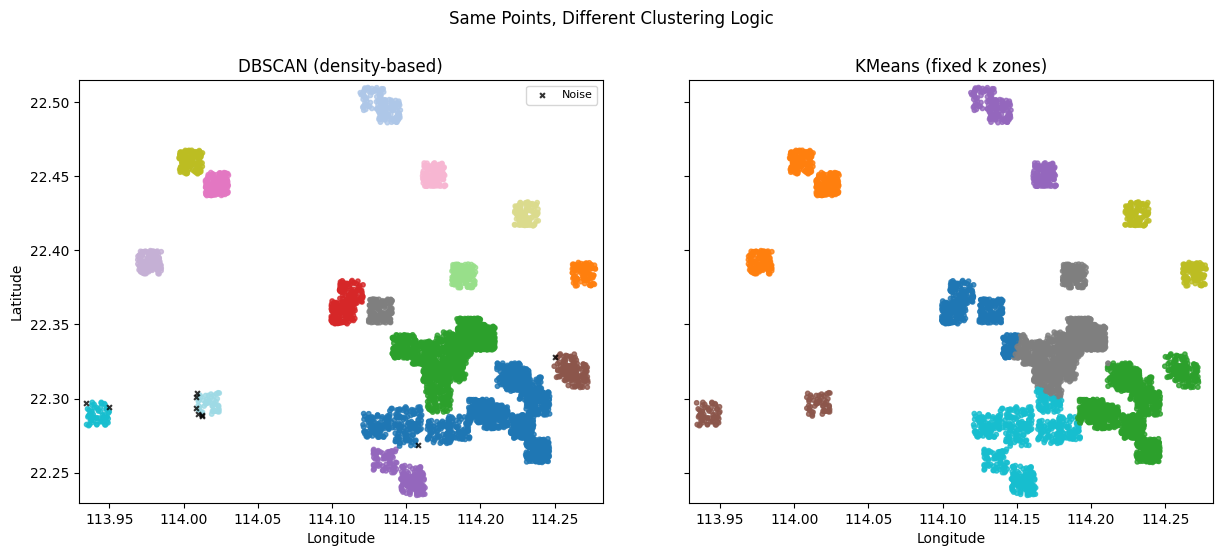

Interpretation tip: ARI near 1.0 means very similar label partitions; near 0 means weak similarity.


,DBSCAN clusters,DBSCAN noise ratio,KMeans clusters,Adjusted Rand (DBSCAN vs KMeans)
0,16,0.0018,8,0.7081


In [86]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import DBSCAN, KMeans
from sklearn.metrics import adjusted_rand_score

# Build a robust comparison frame even if notebook state changed
if 'all_people' not in globals() or not {'latitude', 'longitude'}.issubset(set(all_people.columns)):
    elder_tmp = pd.read_csv('fake_elderly_profiles.csv')
    youth_tmp = pd.read_csv('fake_youth_profiles.csv')
    all_people = pd.concat([elder_tmp, youth_tmp], ignore_index=True)
    all_people = all_people.dropna(subset=['latitude', 'longitude']).copy()
    all_people[['latitude', 'longitude']] = all_people[['latitude', 'longitude']].astype(float)

cmp_df = all_people[['latitude', 'longitude']].copy()

# Ensure DBSCAN labels exist
if 'cluster_id' in all_people.columns:
    cmp_df['cluster_id'] = all_people['cluster_id'].to_numpy()
else:
    eps_km_local = 0.5
    min_samples_local = 12
    eps_rad_local = eps_km_local / 6371.0088
    coords_rad = np.radians(cmp_df[['latitude', 'longitude']].to_numpy())
    cmp_df['cluster_id'] = DBSCAN(
        eps=eps_rad_local,
        min_samples=min_samples_local,
        metric='haversine',
        algorithm='ball_tree'
    ).fit_predict(coords_rad)

# Ensure KMeans labels exist
if 'km_df' in globals() and 'kmeans_cluster' in km_df.columns and len(km_df) == len(cmp_df):
    cmp_df['kmeans_cluster'] = km_df['kmeans_cluster'].to_numpy()
else:
    k_local = 8
    km_local = KMeans(n_clusters=k_local, random_state=42, n_init=20)
    cmp_df['kmeans_cluster'] = km_local.fit_predict(cmp_df[['latitude', 'longitude']].to_numpy())

# Shared bounds so both plots use exactly the same viewport
lat_min, lat_max = cmp_df['latitude'].min() - 0.005, cmp_df['latitude'].max() + 0.005
lon_min, lon_max = cmp_df['longitude'].min() - 0.005, cmp_df['longitude'].max() + 0.005

fig, axes = plt.subplots(1, 2, figsize=(13, 5.2), sharex=True, sharey=True)

# Left: DBSCAN (noise as black x)
db_non_noise = cmp_df[cmp_df['cluster_id'] != -1]
db_noise = cmp_df[cmp_df['cluster_id'] == -1]
axes[0].scatter(
    db_non_noise['longitude'], db_non_noise['latitude'],
    c=db_non_noise['cluster_id'], cmap='tab20', s=10, alpha=0.8
)
if len(db_noise):
    axes[0].scatter(
        db_noise['longitude'], db_noise['latitude'],
        c='black', marker='x', s=12, alpha=0.8, label='Noise'
    )
    axes[0].legend(loc='upper right', fontsize=8)
axes[0].set_title('DBSCAN (density-based)')
axes[0].set_xlabel('Longitude')
axes[0].set_ylabel('Latitude')
axes[0].set_xlim(lon_min, lon_max)
axes[0].set_ylim(lat_min, lat_max)
axes[0].set_aspect('equal', adjustable='box')

# Right: KMeans
axes[1].scatter(
    cmp_df['longitude'], cmp_df['latitude'],
    c=cmp_df['kmeans_cluster'], cmap='tab10', s=10, alpha=0.8
)
axes[1].set_title('KMeans (fixed k zones)')
axes[1].set_xlabel('Longitude')
axes[1].set_xlim(lon_min, lon_max)
axes[1].set_ylim(lat_min, lat_max)
axes[1].set_aspect('equal', adjustable='box')

plt.suptitle('Same Points, Different Clustering Logic', y=1.03)
plt.tight_layout()
plt.show()

# Compact quantitative comparison
db_labels = cmp_df['cluster_id'].to_numpy()
km_labels = cmp_df['kmeans_cluster'].to_numpy()
ari = adjusted_rand_score(km_labels, db_labels)

db_clusters = len(set(db_labels)) - (1 if -1 in db_labels else 0)
db_noise_ratio = float((db_labels == -1).mean())
km_clusters = int(cmp_df['kmeans_cluster'].nunique())

summary = pd.DataFrame([
    {
        'DBSCAN clusters': db_clusters,
        'DBSCAN noise ratio': round(db_noise_ratio, 4),
        'KMeans clusters': km_clusters,
        'Adjusted Rand (DBSCAN vs KMeans)': round(float(ari), 4)
    }
])

print('Interpretation tip: ARI near 1.0 means very similar label partitions; near 0 means weak similarity.')
summary